# The evidence layer on LAsset's own asset lists

**Question.** Does the code-built relationship map add anything to LAsset itself? Every earlier test added the map to
this project's own generator. Here the map is applied to the asset lists the LAsset authors published, with no model
call, so the evidence layer is the only change.

**What the map can say about a LAsset item.** LAsset gives an element name, an entity and prose; no role, no cited line.
The code resolves each item to map elements and reads their relationship profile: what each element drives, what drives
it, whether it is stored, which sub-units it is wired to.

**Two readings, fixed before running** (`assetgen_meta/lasset_layer/PREREG.md`, design v2):
- **H1, audit:** does map evidence rank LAsset's held-out hits above its false positives? A model on the profiles is trained on the tuning modules and scored by AUC (0.5 = chance) on the held-out modules.
- **H2, filter:** does dropping items the model scores low raise held-out precision beyond random removal of the same size? The threshold is fixed on tuning.

The confirmatory reading is the RTL-only list on the 26 held-out modules, with 97.5% intervals (two tests). Everything
else is a secondary row. If neither holds, the claim is "audit trail only".

**Design history.** A first design (v1) was reviewed on the tuning modules and replaced before any held-out reading. Its
trace levels measured version drift and "the element is used", not whether an item is an asset. Section 1 of PREREG.md
has the details.

**Expectation recorded before the held-out reading** (PREREG.md section 4): on tuning, the primary list's model is below
chance (AUC 0.448), and its threshold is 0, so the filter drops nothing. H2 is therefore expected to be "not testable"
and H1 to fail.

No API call anywhere in this notebook. Code: `assetgen_meta/lasset_layer.py` (self-tested against hand-read map lines and
the scorer). Outputs: `assetgen_meta/lasset_layer/`, with a report and an item ledger per list and split.


In [1]:
# Setup: self-test, and refuse to read if a pinned file changed since the pre-registration (no API call)
import os, sys, json, importlib, csv
from pathlib import Path
if Path.cwd().name == "notebooks":            # this notebook lives in notebooks/; every path below is from the repo root
    os.chdir(Path.cwd().parent)
for _p in ("assetgen_meta", "src"):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import fp_diagnosis as fd, fault_reporter as fr, lasset_layer as ll
for _m in (fd, fr, ll):
    importlib.reload(_m)
from IPython.display import Markdown, display
assert ll.selftest(log=lambda *a: None), "lasset_layer self-test failed: do not read"
_changed = ll.verify_pins()
print("self-test PASS; pins:", "all unchanged since the pre-registration" if not _changed else f"CHANGED {_changed}")
assert not _changed, "a pinned file changed after the pre-registration: do not read"


self-test PASS; pins: all unchanged since the pre-registration


## Development reading: the 15 tuning modules (fixes the model and the threshold; no decision rule)

In [2]:
# Tuning: the three published lists (no API call)
TUN = {w: ll.read_tuning(w, log=lambda *a: None) for w in ll.LISTS}
display(Markdown((ll.OUT / "tuning_rtl_only.md").read_text(encoding="utf-8")))


# Evidence layer on LAsset's list `rtl_only` (tuning)

As published: P 0.680, R 0.748, F1 0.712 (122 items, 111 reference entries). P = precision (share of listed items in the reference); R = recall (share of reference entries listed). Labels by the scorer's own matching.

| items | hits | false positives |
|---|---|---|
| single-element (the tested population) | 82 | 26 |
| compound (always kept) | 0 | 11 |
| name not in this RTL version (never dropped) | 1 | 2 |

Trace levels of resolved items (descriptive; T3 = use traced, close to universal):

| | items | T1 no record | T2 records, no use | T3 use traced |
|---|---|---|---|---|
| hits | 82 | 1% | 2% | 96% |
| false positives | 37 | 0% | 5% | 95% |

Resolution rules used: {'R1': 133, 'R2': 3}.

## Development reading (fixes what held-out will use)

- Single-element items: 108. Leave-one-module-out AUC of the map model (hits vs false positives, 0.5 = chance): 0.448.
- Threshold chosen on tuning (leave-one-module-out probabilities, maximizing F1): 0.000; tuning F1 after that filter 0.712 against 0.712 as published.



## Confirmatory reading: the 26 held-out modules

The primary list (RTL-only) decides. The secondary lists use the same procedure with no decision rule. The numbers are
seeded and deterministic, so re-running this cell gives the same reading.


In [3]:
# Held-out: the primary list (decides) and the two secondary lists (no API call)
HO = {w: ll.read_heldout(w, log=lambda *a: None) for w in ll.LISTS}
display(Markdown((ll.OUT / "heldout_rtl_only.md").read_text(encoding="utf-8")))


# Evidence layer on LAsset's list `rtl_only` (heldout)

As published: P 0.730, R 0.757, F1 0.743 (196 items, 189 reference entries). P = precision (share of listed items in the reference); R = recall (share of reference entries listed). Labels by the scorer's own matching.

| items | hits | false positives |
|---|---|---|
| single-element (the tested population) | 142 | 44 |
| compound (always kept) | 0 | 5 |
| name not in this RTL version (never dropped) | 1 | 4 |

Trace levels of resolved items (descriptive; T3 = use traced, close to universal):

| | items | T1 no record | T2 records, no use | T3 use traced |
|---|---|---|---|---|
| hits | 142 | 0% | 1% | 99% |
| false positives | 49 | 0% | 4% | 96% |

Resolution rules used: {'R1': 197, 'R2': 2}.

## H1, audit: does map evidence rank LAsset's held-out hits above its false positives?

Model trained on the tuning single-element items of this list, applied to the 186 held-out single-element items: AUC 0.639 (97.5% module-bootstrap interval 0.495 to 0.768). Within held-out, leave one module out: 0.768 (descriptive).

## H2, filter: does the map-based filter raise LAsset's held-out precision beyond random removal?

Threshold fixed on tuning: 0.000. Dropped 0 single-element items (0 hits, 0 false positives) in 0 modules.

| | P | R | F1 |
|---|---|---|---|
| as published | 0.730 | 0.757 | 0.743 |
| after the filter | 0.730 | 0.757 | 0.743 |

Change in P +0.000 (97.5% interval +0.000 to +0.000); change in R +0.000 (+0.000 to +0.000). Random removal of the same number per module: mean P 0.730 (97.5% range 0.730 to 0.730); share of random draws reaching the filter's P: 100.0%.

## Back-fill (descriptive only)

Added 4 input ports in 3 modules (pool 39), 3 of them hits; list after: P 0.730, R 0.772.

## Pre-registered verdicts (PREREG.md section 3)

- H1, audit (interval lower bound above 0.5): **does not hold**.
- H2, filter (precision interval above 0 and under 2.5% of random removals reaching it; not testable if fewer than 4 modules touched): **not testable**.
- What the data supports: **audit trail only: the map traces LAsset's items but does not tell its hits from its false positives**.



In [4]:
# Summary across lists and splits (only the held-out RTL-only row carries a decision)
_f = lambda x: f"{x:.3f}"
_rows = [f"| tuning | {w} | {_f(r['base']['P'])} / {_f(r['base']['R'])} ({r['base']['emitted']}) | {r['single_items']} | "
         f"LOMO {_f(r['lomo_auc'])} | threshold {_f(r['threshold'])}: F1 {_f(r['base']['F1'])} -> {_f(r['tuning_F1_after_lomo_filter'])} | - |"
         for w, r in TUN.items()]
for w, r in HO.items():
    h1, h2, v = r["H1"], r["H2"], r["verdicts"]
    _rows.append(f"| held-out | {w} | {_f(r['base']['P'])} / {_f(r['base']['R'])} ({r['base']['emitted']}) | {r['single_items']} | "
                 f"{_f(h1['auc'])} [{_f(h1['lo'])}, {_f(h1['hi'])}] | drops {h2['dropped']} in {h2['modules_touched']} modules: P {_f(h2['P'])}, "
                 f"R {_f(h2['R'])} (random reaches it {h2['random']['share_ge']:.1%}) | "
                 + (f"H1 {v['H1_audit']}; H2 {v['H2_filter']}" if "H1_audit" in v else "secondary") + " |")
display(Markdown("| split | list | as published P / R (items) | single-element items | AUC [97.5% CI] | filter | verdicts |\n"
                 "|---|---|---|---|---|---|---|\n" + "\n".join(_rows)
                 + f"\n\n**Confirmatory claim (held-out, RTL-only): {HO['rtl_only']['verdicts']['claim']}.**"))


| split | list | as published P / R (items) | single-element items | AUC [97.5% CI] | filter | verdicts |
|---|---|---|---|---|---|---|
| tuning | rtl_only | 0.680 / 0.748 (122) | 108 | LOMO 0.448 | threshold 0.000: F1 0.712 -> 0.712 | - |
| tuning | spec_rtl | 0.737 / 0.910 (137) | 131 | LOMO 0.676 | threshold 0.322: F1 0.815 -> 0.824 | - |
| tuning | refined | 0.800 / 0.901 (125) | 121 | LOMO 0.600 | threshold 0.000: F1 0.847 -> 0.847 | - |
| held-out | rtl_only | 0.730 / 0.757 (196) | 186 | 0.639 [0.495, 0.768] | drops 0 in 0 modules: P 0.730, R 0.757 (random reaches it 100.0%) | H1 does not hold; H2 not testable |
| held-out | spec_rtl | 0.734 / 0.862 (222) | 217 | 0.674 [0.556, 0.788] | drops 2 in 2 modules: P 0.741, R 0.862 (random reaches it 5.9%) | secondary |
| held-out | refined | 0.791 / 0.862 (206) | 203 | 0.643 [0.493, 0.776] | drops 0 in 0 modules: P 0.791, R 0.862 (random reaches it 100.0%) | secondary |

**Confirmatory claim (held-out, RTL-only): audit trail only: the map traces LAsset's items but does not tell its hits from its false positives.**

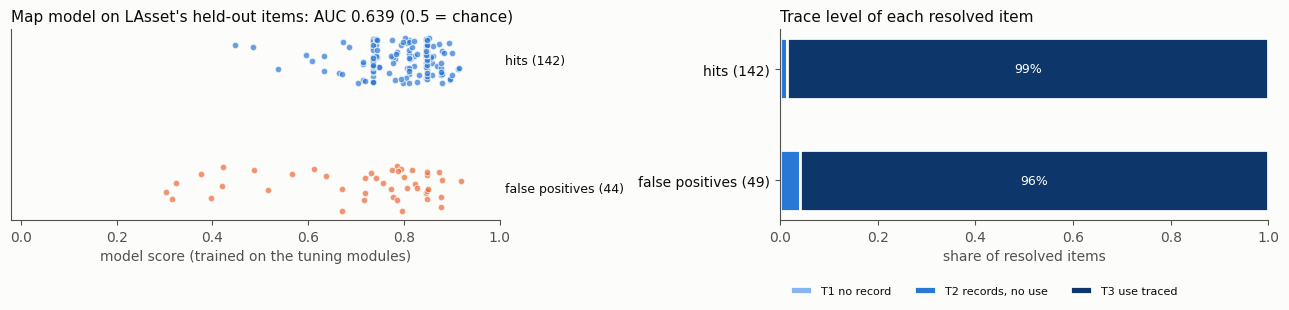

In [5]:
# Charts (held-out, RTL-only): the model's scores for hits and false positives; where the items sit on the trace levels
import matplotlib.pyplot as plt, random as _r
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
HIT, FPC = "#2a78d6", "#eb6834"                                          # categorical slots 1-2 (validated, light)
RAMP = {"T1": "#86b6ef", "T2": "#2a78d6", "T3": "#0d366b"}              # ordinal ramp (validated, light)
WORDS = {"T1": "T1 no record", "T2": "T2 records, no use", "T3": "T3 use traced"}
with open(ll.OUT / "heldout_rtl_only_items.csv", encoding="utf-8") as _fh:
    _items = [x for x in csv.DictReader(_fh) if x["kind"] == "single"]
r = HO["rtl_only"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6), facecolor=SURFACE)
for ax in (a1, a2):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(MUTED); ax.spines["bottom"].set_color(MUTED); ax.tick_params(colors=MUTED)
_g = _r.Random(0)
for y, (lab, col, name) in enumerate((("FP", FPC, "false positives"), ("TP", HIT, "hits"))):
    xs = [float(x["model_probability"]) for x in _items if x["label"] == lab]
    a1.scatter(xs, [y + _g.uniform(-0.18, 0.18) for _ in xs], s=22, color=col, alpha=0.7, edgecolors=SURFACE, linewidths=0.8)
    a1.text(1.01, y, f"{name} ({len(xs)})", va="center", color=INK, fontsize=9, transform=a1.get_yaxis_transform())
a1.set_yticks([]); a1.set_xlim(-0.02, 1.0)
a1.set_xlabel("model score (trained on the tuning modules)", color=MUTED)
a1.set_title(f"Map model on LAsset's held-out items: AUC {r['H1']['auc']:.3f} (0.5 = chance)", color=INK, fontsize=11, loc="left")
tl = r["composition"]["trace_levels"]
for y, (lab, name) in enumerate((("FP", "false positives"), ("TP", "hits"))):
    left = 0.0
    for L in ll.LEVELS:
        w = tl[lab][L] or 0.0
        a2.barh(y, w, left=left, color=RAMP[L], edgecolor=SURFACE, linewidth=2, height=0.55, label=WORDS[L] if y == 0 else None)
        if w >= 0.06:
            a2.text(left + w / 2, y, f"{w:.0%}", ha="center", va="center", color="white" if L != "T1" else INK, fontsize=9)
        left += w
a2.set_yticks([0, 1], [f"false positives ({tl['FP']['n']})", f"hits ({tl['TP']['n']})"], color=INK)
a2.set_xlim(0, 1); a2.set_xlabel("share of resolved items", color=MUTED)
a2.set_title("Trace level of each resolved item", color=INK, fontsize=11, loc="left")
a2.legend(ncol=3, fontsize=8, frameon=False, loc="lower left", bbox_to_anchor=(0, -0.45), labelcolor=INK)
plt.tight_layout(); plt.show()


## How to word the result

The claim follows the rule fixed before the reading (PREREG.md section 3):
- **H1 holds:** "Applied to LAsset's own published RTL-only lists, relationship evidence from a code-built map ranks LAsset's held-out hits above its false positives (AUC x, 97.5% CI [lo, hi]; 26 held-out NEORV32 modules; pre-registered)."
- **H2 holds:** "A map-based filter learnt on 15 tuning modules raised LAsset's held-out precision from p to q (97.5% CI of the gain [lo, hi]) beyond random removal of the same size."
- **Neither holds:** "audit trail only". The map traces every LAsset item that exists in this RTL version to its relationships, but that evidence does not tell its hits from its false positives. This is still a usable result. The item ledger (`assetgen_meta/lasset_layer/heldout_rtl_only_items.csv`) is the audit trail.

Secondary lists (Spec+RTL, refined) are reported without a decision rule. A secondary row that looks better is not evidence for the claim.
